In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import seaborn as sns
import plotly.express as px

import re

from collections import Counter


In [2]:
# Load the dataset
path = Path("language_translation_dataset.csv")

try:
    df = pd.read_csv(path)
    print("Dataset Loaded successfully")
    
except FileNotFoundError:
    print(f"File not found at {path}. Please check the file path and try again.")


Dataset Loaded successfully


Dataset Overview

In [3]:
df = pd.read_csv(path, na_values=['', ' ', 'NA', 'N/A', 'None'])
df.head()

,Sentence_ID,Source_Language,Target_Language,Source_Text,Target_Text,Domain,Sentence_Length,Translation_Quality,Speaker_Region,Formality
0,S0001,English,Luganda,Thank you very much.,[Luganda translation] Webale nnyo,Daily Conversation,4,High,Eastern,Formal
1,S0002,English,Lusoga,The patient needs medicine,[Lusoga translation] Omulwaire yetaaga obulezi,Health,4,High,Central,Informal
2,S0003,English,Luganda,Welcome,[Luganda translation] Tukwaniriza,Tourism,1,High,Western,Informal
3,S0004,English,Runyankole,School begins tomorrow,[Runyankore translation] Eishomero niritandika...,Education,3,High,West Nile,Formal
4,S0005,English,Luganda,Good morning,[Luganda translation] Wasuze otya,Business,2,High,Eastern,Formal


In [4]:
#Shape
df.shape

(2001, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sentence_ID          2001 non-null   str  
 1   Source_Language      2001 non-null   str  
 2   Target_Language      2001 non-null   str  
 3   Source_Text          2001 non-null   str  
 4   Target_Text          2001 non-null   str  
 5   Domain               2001 non-null   str  
 6   Sentence_Length      2001 non-null   str  
 7   Translation_Quality  2001 non-null   str  
 8   Speaker_Region       2001 non-null   str  
 9   Formality            2001 non-null   str  
dtypes: str(10)
memory usage: 156.5 KB


In [6]:
df.describe(include="all")

,Sentence_ID,Source_Language,Target_Language,Source_Text,Target_Text,Domain,Sentence_Length,Translation_Quality,Speaker_Region,Formality
count,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001
unique,1989,1,7,13,108,7,6,1,5,2
top,S0001,English,Acholi,Wash your hands,[Lugbara translation] Ba azoruri le aro,Health,4,High,West Nile,Formal
freq,8,2001,309,192,35,505,680,2001,425,1007


In [7]:
#Missing Values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum()/len(df))*100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_df

,Missing Values,Percentage
Sentence_ID,0,0.0
Source_Language,0,0.0
Target_Language,0,0.0
Source_Text,0,0.0
Target_Text,0,0.0
Domain,0,0.0
Sentence_Length,0,0.0
Translation_Quality,0,0.0
Speaker_Region,0,0.0
Formality,0,0.0


In [8]:
#data types
df.dtypes

Sentence_ID            str
Source_Language        str
Target_Language        str
Source_Text            str
Target_Text            str
Domain                 str
Sentence_Length        str
Translation_Quality    str
Speaker_Region         str
Formality              str
dtype: object

In [9]:
#Duplication
duplicate_count = df.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_count}")

Exact duplicate rows: 6


In [10]:
df[df.duplicated(keep=False)]

,Sentence_ID,Source_Language,Target_Language,Source_Text,Target_Text,Domain,Sentence_Length,Translation_Quality,Speaker_Region,Formality
49,S0001,English,Luganda,The road is bad,[Luganda translation] Ekkubo libi,Agriculture,4,High,Eastern,Formal
55,S0001,English,Luganda,The road is bad,[Luganda translation] Ekkubo libi,Agriculture,4,High,Eastern,Formal
302,S0001,English,Luganda,The road is bad,[Luganda translation] Ekkubo libi,Agriculture,4,High,Eastern,Formal
839,S0001,English,Luganda,The road is bad,[Luganda translation] Ekkubo libi,Agriculture,4,High,Eastern,Formal
1225,S0001,English,Luganda,The road is bad,[Luganda translation] Ekkubo libi,Agriculture,4,High,Eastern,Formal
1434,S0001,English,Luganda,The road is bad,[Luganda translation] Ekkubo libi,Agriculture,4,High,Eastern,Formal
1958,S0001,English,Luganda,The road is bad,[Luganda translation] Ekkubo libi,Agriculture,4,High,Eastern,Formal


In [11]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"After Cleaning: Exact duplicate rows- {df_clean.duplicated().sum()}")

print("Dataset Shape After Removing Duplicates")
df_clean.shape

After Cleaning: Exact duplicate rows- 0
Dataset Shape After Removing Duplicates


(1995, 10)

Data Cleaning and Exploratory Data Analysis

In [12]:
df_text = df_clean[
    [
        "Source_Text",
        "Target_Language",
        "Target_Text"
    ]
].copy()

In [13]:
#Inspect the potential features
df_text.head(10)

,Source_Text,Target_Language,Target_Text
0,Thank you very much.,Luganda,[Luganda translation] Webale nnyo
1,The patient needs medicine,Lusoga,[Lusoga translation] Omulwaire yetaaga obulezi
2,Welcome,Luganda,[Luganda translation] Tukwaniriza
3,School begins tomorrow,Runyankole,[Runyankore translation] Eishomero niritandika...
4,Good morning,Luganda,[Luganda translation] Wasuze otya
5,Thank you,Lusoga,[Lusoga translation] Webale
6,Open the door,Ateso,[Ateso translation] Buka ebwogo.
7,The road is bad,Runyankole,[Runyankole translation] Oruguto nirubi
8,This park has many animals,Lugbara,[Lugbara translation] Jeredigada anakpaki minji
9,This park has many animals,Acholi,[Acholi translation] Kabedo pa lee ni tye ki l...


In [14]:
#Removing the placeholder markers
df_text["Target_Text"] = df_text["Target_Text"].apply(
    lambda x : re.sub(r"\[.*?\]\s*","", x)
)
print("Placehlder marker removal complete")

Placehlder marker removal complete


In [15]:
#Verifying
print("Verifying...")
df_text[
    ["Target_Language", "Target_Text"]
].head(10)

Verifying...


,Target_Language,Target_Text
0,Luganda,Webale nnyo
1,Lusoga,Omulwaire yetaaga obulezi
2,Luganda,Tukwaniriza
3,Runyankole,Eishomero niritandika nyencakare
4,Luganda,Wasuze otya
5,Lusoga,Webale
6,Ateso,Buka ebwogo.
7,Runyankole,Oruguto nirubi
8,Lugbara,Jeredigada anakpaki minji
9,Acholi,Kabedo pa lee ni tye ki lee mapol


In [16]:
#Removing the trailing white space
df_text["Target_Text"] = df_text["Target_Text"].str.strip()
print("White space removal complete")

White space removal complete


In [17]:
#Target Text: Removing any double spaces
df_text["Target_Text"] = (
    df_text["Target_Text"]
    .str.replace(r"\s+", " ", regex=True)
)
print("Double space removal complete")

Double space removal complete


In [18]:
#Checking for variations in spelling for target language
df_text["Target_Language"].value_counts()

Target_Language
Acholi        309
Runyankole    297
Ateso         288
Luganda       287
Lusoga        282
Lugbara       277
Rukiga        255
Name: count, dtype: int64

In [19]:
#Source Text: Removing any double spaces
df_text["Source_Text"] = (
    df_text["Source_Text"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)
print("Double space removal complete")

Double space removal complete


In [20]:
#Running diagnostics across the language
def find_untranslated(df, language=None):
    if language is None:
        subset = df
    else:
        subset = df[df["Target_Language"] == language]

    untranslated = subset[
        subset["Source_Text"].str.strip().str.lower()
        ==
        subset["Target_Text"].str.strip().str.lower()
    ]

    return untranslated

In [21]:
untranslated = find_untranslated(df_text)
untranslated

,Source_Text,Target_Language,Target_Text
833,The road is bad,Rukiga,The road is bad


In [22]:
#Dropping the untranslated row
df_text = df_text.drop(untranslated.index)
df_text = df_text.reset_index(drop=True)
print("Dropped untranslated row")

Dropped untranslated row


In [23]:
#Finding empty translations after removing the placeholders
def find_empty_targets(df):

    empty = df[
        df["Target_Text"].str.strip() == ""
    ]

    return empty

In [24]:
empty = find_empty_targets(df_text)
empty

,Source_Text,Target_Language,Target_Text


In [25]:
#Displays every English sentence together with all of its unique translations for a given language.
def inspect_translations(df, language):

    subset = df[df["Target_Language"] == language]

    grouped = (
        subset
        .groupby("Source_Text")["Target_Text"]
        .unique()
    )

    return grouped

In [26]:
#Formats the translations
def print_translations(df, language):

    grouped = inspect_translations(df, language)

    for english, translations in grouped.items():

        print("=" * 60)
        print(f"English: {english}")

        for i, translation in enumerate(translations, start=1):
            print(f"{i}. {translation}")

        print()

In [27]:
runyankole = print_translations(
    df_text,
    "Runyankole"
)

runyankole

English: Good morning
1. Oreire ota
2. Oraire ota
3. Oreiregye

English: Open the door
1. Yigura orwigyi
2. YIgura orwigyi

English: School begins tomorrow
1. Eishomero niritandika nyencakare
2. Isomero niritandika nkyakare

English: Thank you
1. Webale
2. Twakushemererwa
3. Webare

English: The crops are ready
1. Ebihingwa byahaire

English: The market is busy today
1. Akatare kali busy

English: The patient needs medicine
1. Omurwire nayenda omubazi

English: The road is bad
1. Oruguto nirubi
2. oruguto nirubi

English: This park has many animals
1. Ekishaka kyiine ebinyamaiswa bingi
2. Ebihingwa byahaire
3. Ekishaka kyiine ebinyamaiswa nyingi

English: Wash your hands
1. Naba engaro
2. Naba engaro zaawe
3. Naba Engaro

English: We are going home
1. Turiho ntuza omuka
2. Turiyo nituza omuka
3. Yigura orwigyi
4. Nitugyenda omuka
5. Turiyo Nitutaha omuka
6. Turiyo nitutaha omuka

English: Welcome
1. Twakushemererwa



In [28]:
rukiga = print_translations(
    df_text,
    "Rukiga"
)

rukiga

English: Good morning
1. Bwashesha gye

English: Open the door
1. Yaigura orwigi

English: School begins tomorrow
1. Eishomero niritandika nyencakare

English: Thank you
1. Webare

English: The crops are ready
1. Ebihingwa byezire

English: The market is busy today
1. Akatare kijwire erizoba

English: The patient needs medicine
1. Omurwaire nayetenga embazi

English: The road is bad
1. Oruguuto nirubi

English: This park has many animals
1. Paaka egi erimu enyamaishwa mingi
2. Paaka egi erimu enyamaiswa mingi

English: Wash your hands
1. Naaba engaro zaawe

English: We are going home
1. Turiyo nituza omuka

English: Welcome
1. Twakwakiira



In [29]:
lusoga = print_translations(
    df_text,
    "Lusoga"
)

lusoga

English: Good morning
1. Wasuze otya

English: Open the door
1. Igulawo olwigi

English: School begins tomorrow
1. Eisomero litandika idho

English: Thank you
1. Webale

English: The crops are ready
1. Ebisimbe byatuuka

English: The market is busy today
1. Akatale kalimu abantu kamala olwalelo

English: The patient needs medicine
1. Omulwaire yetaaga obulezi

English: The road is bad
1. Oluguudo lubi

English: This park has many animals
1. Paaka eno elina ensolo kamaala

English: Wash your hands
1. Naaba engalo dho

English: We are going home
1. Tuli kugya waka

English: Welcome
1. Tusangaile



In [30]:
luganda = print_translations(
    df_text,
    "Luganda"
)

luganda

English: Good morning
1. Wasuze otya

English: Open the door
1. Ggulawo oluggi

English: School begins tomorrow
1. Essomero litandika enkya

English: Thank you
1. Webale
2. Webale nnyo

English: Thank you very much.
1. Webale nnyo

English: The crops are ready
1. Ebirime bikuze

English: The market is busy today
1. Akatale kaliimu abantu bangi leero

English: The patient needs medicine
1. Omulwadde yeetaaga eddagala

English: The road is bad
1. Ekkubo libi

English: This park has many animals
1. Paaka eno erimu ensolo nyingi

English: Wash your hands
1. Naaba emikono gyo

English: We are going home
1. Tugenda waka

English: Welcome
1. Tukwaniriza



In [31]:
acholi = print_translations(
    df_text,
    "Acholi"
)

acholi

English: Good morning
1. Icoo Maber
2. Wu coo Maber

English: Open the door
1. Yab doggola

English: School begins tomorrow
1. Gang Kwan obi cake diki

English: Thank you
1. Apwoyo
2. Apwoya wun weng

English: The crops are ready
1. Jami ma ki pito dong tye atera

English: The market is busy today
1. Cuk tye ka tic matek tin

English: The patient needs medicine
1. Latwo ni mito yat

English: The road is bad
1. Gudu ni rac

English: This park has many animals
1. Kabedo pa lee ni tye ki lee mapol

English: Wash your hands
1. Lwok cingi

English: We are going home
1. Watye ka dok gang

English: Welcome
1. Wa joli



In [32]:
ateso = print_translations(
    df_text,
    "Ateso"
)

ateso

English: Good morning
1. Ber otingela.

English: Open the door
1. Buka ebwogo.

English: School begins tomorrow
1. Egenu esomero emoi

English: Thank you
1. Eyalama noi.

English: The crops are ready
1. Ebaret ekeda aiyare.

English: The market is busy today
1. Ipu etunya osokoni

English: The patient needs medicine
1. Ekotosi adeka ekia

English: The road is bad
1. Ebarabara ekeda aiboroit.

English: This park has many animals
1. Epu eitur awujo

English: Wash your hands
1. Elota akani

English: We are going home
1. Alototo oire

English: Welcome
1. Ijalama anyin



In [33]:
lugbara = print_translations(
    df_text,
    "Lugbara"
)

lugbara

English: Good morning
1. Mi afu ngoni

English: Open the door
1. Indi kati

English: School begins tomorrow
1. Sukulu la ido dusi

English: Thank you
1. Awodifo

English: The crops are ready
1. Nyaka afukibo

English: The market is busy today
1. Su fi andu

English: The patient needs medicine
1. Ba azoruri le aro

English: The road is bad
1. Njila unji

English: This park has many animals
1. Jeredigada anakpaki minji

English: Wash your hands
1. Mi uji midriki

English: We are going home
1. Ama mu akuwa

English: Welcome
1. Ma ai mira



In [34]:
#Correcting the translations (Sentences)
sentence_corrections = {
    ("Runyankole","School begins tomorrow","Isomero niritandika nkyakare"): "Eishomero niritandika nyencakare",
    ("Runyankole","Thank you","Webale"): "Webare",
    ("Runyankole","The road is bad","oruguto nirubi"): "Oruguto nirubi",
    ("Runyankole","Thank you", "Twakushemererwa"): "Webare",
    ("Runyankole","Good morning", "Oreire ota"): "Oraire ota",
    ("Runyankole","The market is busy today","Akatare kali busy"): "Akatare kari omu kazi erizooba",
    ("Runyankole","Wash your hands","Naba Engaro"): "Naba engaro",
    ("Runyankole","We are going home","Turiho ntuza omuka"): "Nitugyenda omuka",
    ("Runyankole","We are going home","Turiyo nituza omuka"): "Nitugyenda omuka",
    ("Runyankole","We are going home", "Yigura orwigyi"): "Nitugyenda omuka",
    ("Runyankole","We are going home","Turiyo Nitutaha omuka"): "Nitugyenda omuka",
    ("Runyankole","We are going home","Turiyo nitutaha omuka"): "Nitugyenda omuka",    
   ("Rukiga","This park has many animals" ,"Paaka egi erimu enyamaishwa mingi"): "Paaka egi erimu enyamaishwa nyingyi",
    ("Rukiga","This park has many animals", "Paaka egi erimu enyamaiswa mingi"): "Paaka egi erimu ebinyamaiswa bingi",
    ("Runyankole","This park has many animals","Ekishaka kyiine ebinyamaiswa bingi"): "Irindiro ryenyamaiswa ririmu enyamaiswa nyingi",
    ("Runyankole","This park has many animals","Ebihingwa byahaire"): "Irindiro ryenyamaiswa ririmu enyamaiswa nyingi",
    ("Runyankole","This park has many animals", "Ekishaka kyiine ebinyamaiswa nyingi"): "Irindiro ryenyamaiswa ririmu enyamaiswa nyingi",
    ("Luganda","Thank you", "Webale nnyo"): "Webale",
    ("Runyankole","Open the door","YIgura orwigyi"): "Yigura orwigyi"
}

def correct_sentence(row):

    key = (
        row["Target_Language"],
        row["Source_Text"],
        row["Target_Text"]
    )

    if key in sentence_corrections:
        return sentence_corrections[key]

    return row["Target_Text"]

df_text["Target_Text"] = df_text.apply(
    correct_sentence,
    axis=1
)
print("Replacement complete")

Replacement complete


In [35]:
luganda = print_translations(
    df_text,
    "Luganda"
)

luganda

English: Good morning
1. Wasuze otya

English: Open the door
1. Ggulawo oluggi

English: School begins tomorrow
1. Essomero litandika enkya

English: Thank you
1. Webale

English: Thank you very much.
1. Webale nnyo

English: The crops are ready
1. Ebirime bikuze

English: The market is busy today
1. Akatale kaliimu abantu bangi leero

English: The patient needs medicine
1. Omulwadde yeetaaga eddagala

English: The road is bad
1. Ekkubo libi

English: This park has many animals
1. Paaka eno erimu ensolo nyingi

English: Wash your hands
1. Naaba emikono gyo

English: We are going home
1. Tugenda waka

English: Welcome
1. Tukwaniriza



In [36]:
runyankole = print_translations(
    df_text,
    "Runyankole"
)

runyankole

English: Good morning
1. Oraire ota
2. Oreiregye

English: Open the door
1. Yigura orwigyi

English: School begins tomorrow
1. Eishomero niritandika nyencakare

English: Thank you
1. Webare

English: The crops are ready
1. Ebihingwa byahaire

English: The market is busy today
1. Akatare kari omu kazi erizooba

English: The patient needs medicine
1. Omurwire nayenda omubazi

English: The road is bad
1. Oruguto nirubi

English: This park has many animals
1. Irindiro ryenyamaiswa ririmu enyamaiswa nyingi

English: Wash your hands
1. Naba engaro
2. Naba engaro zaawe

English: We are going home
1. Nitugyenda omuka

English: Welcome
1. Twakushemererwa



In [37]:
rukiga = print_translations(
    df_text,
    "Rukiga"
)

rukiga

English: Good morning
1. Bwashesha gye

English: Open the door
1. Yaigura orwigi

English: School begins tomorrow
1. Eishomero niritandika nyencakare

English: Thank you
1. Webare

English: The crops are ready
1. Ebihingwa byezire

English: The market is busy today
1. Akatare kijwire erizoba

English: The patient needs medicine
1. Omurwaire nayetenga embazi

English: The road is bad
1. Oruguuto nirubi

English: This park has many animals
1. Paaka egi erimu enyamaishwa nyingyi
2. Paaka egi erimu ebinyamaiswa bingi

English: Wash your hands
1. Naaba engaro zaawe

English: We are going home
1. Turiyo nituza omuka

English: Welcome
1. Twakwakiira



In [38]:
#Finding exact duplicates
df_text.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1989     True
1990     True
1991     True
1992     True
1993     True
Length: 1994, dtype: bool

In [39]:
print("Dropping Duplicates...")
df_text = (
    df_text
    .drop_duplicates()
    .reset_index(drop=True)
)
print("Dropping complete")

Dropping Duplicates...
Dropping complete


In [40]:
df_text.duplicated().sum()

np.int64(0)

In [41]:
df_text.shape

(90, 3)

In [42]:
df_text

,Source_Text,Target_Language,Target_Text
0,Thank you very much.,Luganda,Webale nnyo
1,The patient needs medicine,Lusoga,Omulwaire yetaaga obulezi
2,Welcome,Luganda,Tukwaniriza
3,School begins tomorrow,Runyankole,Eishomero niritandika nyencakare
4,Good morning,Luganda,Wasuze otya
...,...,...,...
85,Thank you,Acholi,Apwoya wun weng
86,Good morning,Runyankole,Oreiregye
87,This park has many animals,Rukiga,Paaka egi erimu ebinyamaiswa bingi
88,Wash your hands,Runyankole,Naba engaro zaawe


In [43]:
#English: Finding the length of the sentences
def analyze_language(data, column):
    count_value = data[column].value_counts()
    no_unique_values = data[column].nunique()
    
    #Sentence Length
    sentence_length = data[column].apply(
    lambda x: len(x.split())
    )
    
    #Vocabulary Size
    lang_words = " ".join(data[column]).split()
    lang_vocab = len(set(lang_words))
    
    #Most Common
    lang_freq = Counter(lang_words)
    most_common = lang_freq.most_common(15)
    
    #Least common words
    least_common = sorted(lang_freq.items(), key=lambda x: x[1])[:5]
    
    # Rare words
    rare_words = {
        word: count 
        for word, count in lang_freq.items()
        if count == 1
    }

    rare_percentage = (len(rare_words) / lang_vocab) * 100
    
    #Lexical Analysis
    total_words = len(lang_words)

    lexical_diversity = lang_vocab / total_words
    
    return {
        "sentence_frequency": count_value,
        "number_of_unique_sentences": no_unique_values,
        "sentence_length" : sentence_length,
        "length_summary": sentence_length.describe().round(2),
        "vocab_size": lang_vocab,
        "most_common_words" : most_common,
        "least_common_words" : least_common,
        "rare_percentage": rare_percentage,
        "rare_words": rare_words,
        "lexical_diversity" : lexical_diversity
    }
    


In [44]:
english = analyze_language(df_text, "Source_Text")
english

{'sentence_frequency': Source_Text
 Good morning                  9
 Thank you                     8
 This park has many animals    8
 Wash your hands               8
 The patient needs medicine    7
 Welcome                       7
 School begins tomorrow        7
 Open the door                 7
 The road is bad               7
 The crops are ready           7
 We are going home             7
 The market is busy today      7
 Thank you very much.          1
 Name: count, dtype: int64,
 'number_of_unique_sentences': 13,
 'sentence_length': 0     4
 1     4
 2     1
 3     3
 4     2
      ..
 85    2
 86    2
 87    5
 88    3
 89    2
 Name: Source_Text, Length: 90, dtype: int64,
 'length_summary': count    90.00
 mean      3.31
 std       1.19
 min       1.00
 25%       2.00
 50%       3.00
 75%       4.00
 max       5.00
 Name: Source_Text, dtype: float64,
 'vocab_size': 37,
 'most_common_words': [('The', 28),
  ('is', 14),
  ('are', 14),
  ('Thank', 9),
  ('you', 9),
  ('Good', 9)

Luganda Analysis

In [45]:
luganda_df = df_text[df_text["Target_Language"] == "Luganda"]
luganda = analyze_language(luganda_df, "Target_Text")
luganda

{'sentence_frequency': Target_Text
 Webale nnyo                           1
 Tukwaniriza                           1
 Wasuze otya                           1
 Ebirime bikuze                        1
 Webale                                1
 Ekkubo libi                           1
 Ggulawo oluggi                        1
 Naaba emikono gyo                     1
 Akatale kaliimu abantu bangi leero    1
 Paaka eno erimu ensolo nyingi         1
 Essomero litandika enkya              1
 Omulwadde yeetaaga eddagala           1
 Tugenda waka                          1
 Name: count, dtype: int64,
 'number_of_unique_sentences': 13,
 'sentence_length': 0     2
 2     1
 4     2
 14    2
 15    1
 38    2
 40    2
 47    3
 58    5
 68    5
 69    3
 71    3
 82    2
 Name: Target_Text, dtype: int64,
 'length_summary': count    13.00
 mean      2.54
 std       1.27
 min       1.00
 25%       2.00
 50%       2.00
 75%       3.00
 max       5.00
 Name: Target_Text, dtype: float64,
 'vocab_size': 32

Lusoga Analysis

In [46]:
lusoga_df = df_text[df_text["Target_Language"] == "Lusoga"]
lusoga = analyze_language(lusoga_df, "Target_Text")
lusoga

{'sentence_frequency': Target_Text
 Omulwaire yetaaga obulezi                1
 Webale                                   1
 Paaka eno elina ensolo kamaala           1
 Oluguudo lubi                            1
 Eisomero litandika idho                  1
 Ebisimbe byatuuka                        1
 Tuli kugya waka                          1
 Akatale kalimu abantu kamala olwalelo    1
 Naaba engalo dho                         1
 Igulawo olwigi                           1
 Tusangaile                               1
 Wasuze otya                              1
 Name: count, dtype: int64,
 'number_of_unique_sentences': 12,
 'sentence_length': 1     3
 5     1
 16    5
 21    2
 34    3
 54    2
 55    3
 57    5
 61    3
 64    2
 65    1
 76    2
 Name: Target_Text, dtype: int64,
 'length_summary': count    12.00
 mean      2.67
 std       1.30
 min       1.00
 25%       2.00
 50%       2.50
 75%       3.00
 max       5.00
 Name: Target_Text, dtype: float64,
 'vocab_size': 32,
 'most_commo

Lugbara Analysis

In [47]:
lugbara_df = df_text[df_text["Target_Language"] == "Lugbara"]
lugbara = analyze_language(lugbara_df, "Target_Text")
lugbara

{'sentence_frequency': Target_Text
 Jeredigada anakpaki minji    1
 Ma ai mira                   1
 Ba azoruri le aro            1
 Sukulu la ido dusi           1
 Mi uji midriki               1
 Nyaka afukibo                1
 Ama mu akuwa                 1
 Njila unji                   1
 Indi kati                    1
 Su fi andu                   1
 Mi afu ngoni                 1
 Awodifo                      1
 Name: count, dtype: int64,
 'number_of_unique_sentences': 12,
 'sentence_length': 8     3
 12    3
 23    4
 27    4
 33    3
 46    2
 52    3
 56    2
 66    2
 72    3
 73    3
 77    1
 Name: Target_Text, dtype: int64,
 'length_summary': count    12.00
 mean      2.75
 std       0.87
 min       1.00
 25%       2.00
 50%       3.00
 75%       3.00
 max       4.00
 Name: Target_Text, dtype: float64,
 'vocab_size': 32,
 'most_common_words': [('Mi', 2),
  ('Jeredigada', 1),
  ('anakpaki', 1),
  ('minji', 1),
  ('Ma', 1),
  ('ai', 1),
  ('mira', 1),
  ('Ba', 1),
  ('azoruri'

Ateso Analysis

In [48]:
ateso_df = df_text[df_text["Target_Language"] == "Ateso"]
ateso = analyze_language(ateso_df, "Target_Text")
ateso

{'sentence_frequency': Target_Text
 Buka ebwogo.                 1
 Ebaret ekeda aiyare.         1
 Ebarabara ekeda aiboroit.    1
 Elota akani                  1
 Epu eitur awujo              1
 Alototo oire                 1
 Eyalama noi.                 1
 Egenu esomero emoi           1
 Ber otingela.                1
 Ijalama anyin                1
 Ekotosi adeka ekia           1
 Ipu etunya osokoni           1
 Name: count, dtype: int64,
 'number_of_unique_sentences': 12,
 'sentence_length': 6     2
 17    3
 19    3
 28    2
 39    3
 42    2
 44    2
 59    3
 62    2
 63    2
 67    3
 75    3
 Name: Target_Text, dtype: int64,
 'length_summary': count    12.00
 mean      2.50
 std       0.52
 min       2.00
 25%       2.00
 50%       2.50
 75%       3.00
 max       3.00
 Name: Target_Text, dtype: float64,
 'vocab_size': 29,
 'most_common_words': [('ekeda', 2),
  ('Buka', 1),
  ('ebwogo.', 1),
  ('Ebaret', 1),
  ('aiyare.', 1),
  ('Ebarabara', 1),
  ('aiboroit.', 1),
  ('Elota',

Acholi Analysis

In [49]:
acholi_df = df_text[df_text["Target_Language"] == "Acholi"]
acholi = analyze_language(acholi_df, "Target_Text")
acholi

{'sentence_frequency': Target_Text
 Kabedo pa lee ni tye ki lee mapol    1
 Icoo Maber                           1
 Latwo ni mito yat                    1
 Wa joli                              1
 Jami ma ki pito dong tye atera       1
 Gang Kwan obi cake diki              1
 Gudu ni rac                          1
 Apwoyo                               1
 Lwok cingi                           1
 Watye ka dok gang                    1
 Cuk tye ka tic matek tin             1
 Yab doggola                          1
 Apwoya wun weng                      1
 Wu coo Maber                         1
 Name: count, dtype: int64,
 'number_of_unique_sentences': 14,
 'sentence_length': 9     8
 10    2
 11    4
 26    2
 41    7
 43    5
 48    3
 49    1
 51    2
 60    4
 70    6
 78    2
 85    3
 89    3
 Name: Target_Text, dtype: int64,
 'length_summary': count    14.00
 mean      3.71
 std       2.09
 min       1.00
 25%       2.00
 50%       3.00
 75%       4.75
 max       8.00
 Name: Target_Tex

Rukiga Analysis

In [50]:
rukiga_df = df_text[df_text["Target_Language"] == "Rukiga"]
rukiga = analyze_language(rukiga_df, "Target_Text")
rukiga

{'sentence_frequency': Target_Text
 Twakwakiira                            1
 Omurwaire nayetenga embazi             1
 Naaba engaro zaawe                     1
 Eishomero niritandika nyencakare       1
 Turiyo nituza omuka                    1
 Bwashesha gye                          1
 Akatare kijwire erizoba                1
 Webare                                 1
 Yaigura orwigi                         1
 Oruguuto nirubi                        1
 Paaka egi erimu enyamaishwa nyingyi    1
 Ebihingwa byezire                      1
 Paaka egi erimu ebinyamaiswa bingi     1
 Name: count, dtype: int64,
 'number_of_unique_sentences': 13,
 'sentence_length': 22    1
 29    3
 30    3
 31    3
 32    3
 35    2
 36    3
 37    1
 74    2
 80    2
 81    5
 83    2
 87    5
 Name: Target_Text, dtype: int64,
 'length_summary': count    13.00
 mean      2.69
 std       1.25
 min       1.00
 25%       2.00
 50%       3.00
 75%       3.00
 max       5.00
 Name: Target_Text, dtype: float64,
 'vo

In [51]:
runyankole_df = df_text[df_text["Target_Language"] == "Runyankole"]
runyankole = analyze_language(runyankole_df, "Target_Text")
runyankole

{'sentence_frequency': Target_Text
 Eishomero niritandika nyencakare                  1
 Oruguto nirubi                                    1
 Webare                                            1
 Yigura orwigyi                                    1
 Ebihingwa byahaire                                1
 Naba engaro                                       1
 Nitugyenda omuka                                  1
 Akatare kari omu kazi erizooba                    1
 Twakushemererwa                                   1
 Irindiro ryenyamaiswa ririmu enyamaiswa nyingi    1
 Oraire ota                                        1
 Omurwire nayenda omubazi                          1
 Oreiregye                                         1
 Naba engaro zaawe                                 1
 Name: count, dtype: int64,
 'number_of_unique_sentences': 14,
 'sentence_length': 3     3
 7     2
 13    1
 18    2
 20    2
 24    2
 25    2
 45    5
 50    1
 53    5
 79    2
 84    3
 86    1
 88    3
 Name: Target_T

Visualizations

Sentence Length Analysis

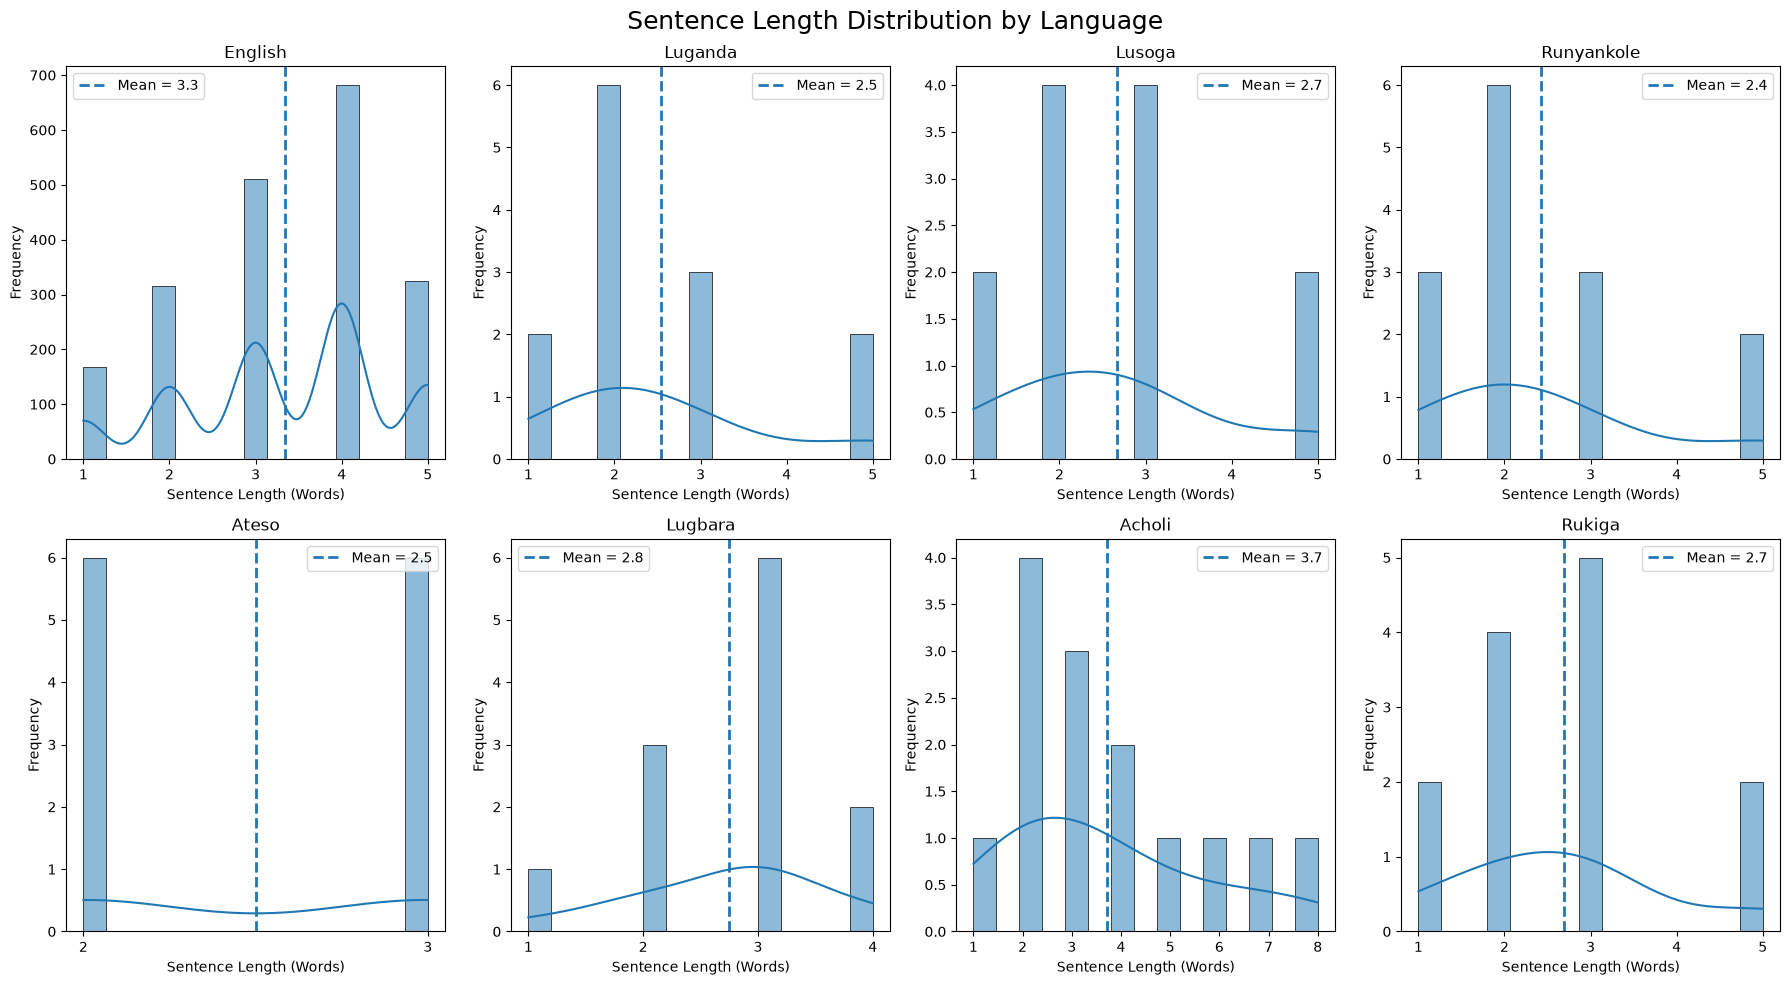

In [52]:
#Sentence Length Analysis
analysis = {}

analysis["English"] = analyze_language(df, "Source_Text")

for language in df_clean["Target_Language"].unique():
    analysis[language] = analyze_language(
        df_text[df_text["Target_Language"] == language],
        "Target_Text"
    )

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for ax, (language, results) in zip(axes.flat, analysis.items()):

    sns.histplot(
        results["sentence_length"],
        bins=15,
        kde=True,
        edgecolor="black",
        linewidth=0.5,
        ax=ax
    )

    mean = results["sentence_length"].mean()

    ax.axvline(
        mean,
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean:.1f}"
    )

    ax.set_title(f"{language}")
    ax.set_xlabel("Sentence Length (Words)")
    ax.set_ylabel("Frequency")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend()

plt.suptitle("Sentence Length Distribution by Language", fontsize=18)
plt.tight_layout()

plt.savefig("images/sentence_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [53]:
eng_len_percent = (analysis["English"]["sentence_length"] <= 4).mean() * 100
lug_len_percent = (analysis["Luganda"]["sentence_length"] <= 3).mean() * 100
lus_len_percent = (analysis["Lusoga"]["sentence_length"] <= 3).mean() * 100
ach_len_percent = (analysis["Acholi"]["sentence_length"] <= 6).mean() * 100
run_len_percent = (analysis["Runyankole"]["sentence_length"] <= 3).mean() * 100
ruk_len_percent = (analysis["Rukiga"]["sentence_length"] <= 3).mean() * 100
ateso_len_percent = (analysis["Ateso"]["sentence_length"] <= 3).mean() * 100
lugb_len_percent = (analysis["Lugbara"]["sentence_length"] <= 3).mean() * 100

percent = {"English sentence length percentage":eng_len_percent, 
           "Luganda sentence length percentage":lug_len_percent, 
           "Lusoga sentence length percentage":lus_len_percent, 
           "Acholi sentence length percentage":ach_len_percent, 
           "Runyankole sentence length percentage":run_len_percent, 
           "Rukiga sentence length percentage":ruk_len_percent, 
           "Ateso sentence length percentage":ateso_len_percent, 
           "Lugbara sentence length percentage":lugb_len_percent
           }
for key, value in percent.items():
    print(f"{key}: {value:.2f}")


English sentence length percentage: 83.76
Luganda sentence length percentage: 84.62
Lusoga sentence length percentage: 83.33
Acholi sentence length percentage: 85.71
Runyankole sentence length percentage: 85.71
Rukiga sentence length percentage: 84.62
Ateso sentence length percentage: 100.00
Lugbara sentence length percentage: 83.33


In [54]:
summary_df = pd.DataFrame({
    "Language": list(analysis.keys()),
    "Vocabulary Size": [
        r["vocab_size"] for r in analysis.values()
    ],
    "Lexical Diversity": [
        r["lexical_diversity"] for r in analysis.values()
    ],
    "Rare Word Percentage": [
        r["rare_percentage"] for r in analysis.values()
    ]
})

Rare Word Percentage

In [55]:
fig = px.bar(
    summary_df,
    x="Language",
    y="Rare Word Percentage",
    color="Language",
    title="Rare Word Percentage Across Languages",
    labels={
        "Language": "Language",
        "Rare Word Percentage": "Rare Word Percentage"
    }
)

fig.write_image("images/rare_word_percentage.png")
fig.show()

Language Distribution

In [56]:
language_counts = (
    df_text["Target_Language"]
    .value_counts()
    .rename_axis("Language")
    .reset_index(name="Count")
)


fig = px.bar(
    language_counts,
    x="Language",
    y="Count",
    color="Language",
    title="Distribution of Target Languages"
)

fig.write_image("images/language_count.png")
fig.show()

Vocabulary

In [57]:
fig = px.bar(
    summary_df,
    x="Vocabulary Size",
    y="Language",
    orientation="h",
    text="Vocabulary Size",
    color="Vocabulary Size",
    title="Vocabulary Size Across Languages"
)

fig.update_layout(
    yaxis_title="Language",
    xaxis_title="Vocabulary Size",
    title_x=0.5
)

fig.write_image("images/vocabulary_size.png")
fig.show()

Lexical Diversity

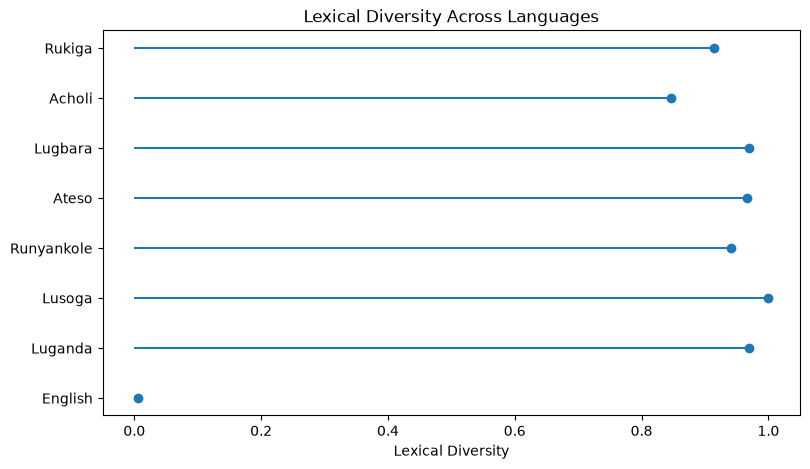

In [58]:
plt.figure(figsize=(9,5))

# draw the stems
plt.hlines(
    y=summary_df["Language"],
    xmin=0,
    xmax=summary_df["Lexical Diversity"]
)

# draw the dots
plt.plot(
    summary_df["Lexical Diversity"],
    summary_df["Language"],
    "o"
)

plt.xlabel("Lexical Diversity")
plt.title("Lexical Diversity Across Languages")
plt.savefig("images/lexical_diversity.png", dpi=300, bbox_inches='tight')

plt.show()

Saving the dataset

In [59]:
#Saving the Cleaned dataset
df_text.to_csv("clean_dataset.csv", index=False)